Importowanie bibliotek

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections.abc import Callable

Generowanie węzłów

In [3]:
def generate_uniform_nodes(n: int, interval: tuple[np.float64, np.float64], f: Callable[[np.float64], np.float64]) -> np.ndarray:
    xs = np.linspace(interval[0], interval[1], n)
    return np.array([(xs[i], f(xs[i])) for i in range(n)], dtype=np.float64)

def generate_chebyshev_nodes(n: int, interval: tuple[np.float64, np.float64], f: Callable[[np.float64], np.float64]) -> np.ndarray:
    a, b = interval[0], interval[1]
    n -= 2
    roots = [-1] + [np.cos((2*k - 1)/(2 * n) * np.pi) for k in range(1, n+1)] + [1]
    xs = [(a+b)/2 + (b-a)/2 * root for root in roots]
    return np.array([(xs[i], f(xs[i])) for i in range(n+2)], dtype=np.float64)

Interpolacja funkcjami sklejanymi 2-go stopnia

In [4]:
def quadratic_spline_interpolation(nodes, function_derivative, boundary_condition):
  n = len(nodes)
  xs = nodes[:, 0]
  ys = nodes[:, 1]

  a = [0.0] * (n - 1)
  b = [0.0] * n
  c = [0.0] * (n - 1)
  
  h = [xs[i+1] - xs[i] for i in range(n-1)]
  
  A = np.zeros((n, n))
  B = np.zeros(n)
  
  if boundary_condition == "f":
    A[0, 0] = 1.0
    B[0] = 0.0
  elif boundary_condition == "c":
    deriv_x1 = function_derivative(xs[0])
    A[0, 0] = -1.0
    A[0, 1] = 1.0
    B[0] = 0.5 * deriv_x1 * h[0]
  
  for i in range(1, n):
    A[i, i-1] = 1.0
    A[i, i] = 1.0
    B[i] = 2 * (ys[i] - ys[i-1]) / h[i-1]
  
  b = np.linalg.solve(A, B)
  
  for i in range(n-1):
    c[i] = ys[i]
    a[i] = (b[i+1] - b[i]) / (2 * h[i])
  
  def interpolation(x):
    i = 0
    while i < n-1 and x > xs[i+1]:
      i += 1
    
    if i == n-1:
      i = n-2
    return a[i] * (x - xs[i])**2 + b[i] * (x - xs[i]) + c[i]

  return interpolation

Interpolacja funkcjami sklejanymi 3-go stopnia

In [5]:
def cubic_spline_interpolation(nodes, boundary_condition):
  n = len(nodes)
  xs = nodes[:, 0]
  ys = nodes[:, 1]
  
  h = [xs[i+1] - xs[i] for i in range(n-1)]
  
  A = np.zeros((n, n))
  b = np.zeros(n)
  
  for i in range(1, n-1):
    A[i, i-1] = h[i-1]
    A[i, i] = 2 * (h[i-1] + h[i])
    A[i, i+1] = h[i]
    
    b[i] = 6 * ((ys[i+1] - ys[i]) / h[i] - (ys[i] - ys[i-1]) / h[i-1])
  
  if boundary_condition == "f":
      A[0, 0] = 1.0
      A[n-1, n-1] = 1.0
      b[0] = 0.0
      b[n-1] = 0.0
      
  elif boundary_condition == "nk":
    if n > 3:
      A[0, 0] = h[1]
      A[0, 1] = -(h[0] + h[1])
      A[0, 2] = h[0]
      b[0] = 0.0
      
      A[n-1, n-3] = h[n-2]
      A[n-1, n-2] = -(h[n-3] + h[n-2])
      A[n-1, n-1] = h[n-3]
      b[n-1] = 0.0
    else:
      A[0, 0] = 1.0
      A[n-1, n-1] = 1.0
      b[0] = 0.0
      b[n-1] = 0.0

  M = np.linalg.solve(A, b)
  
  a = [0.0] * (n-1)
  b = [0.0] * (n-1)
  c = [0.0] * (n-1)
  d = [0.0] * (n-1)
  
  for i in range(n-1):
    a[i] = (M[i+1] - M[i]) / (6 * h[i])
    b[i] = M[i] / 2
    c[i] = (ys[i+1] - ys[i]) / h[i] - h[i] * (M[i+1] + 2 * M[i]) / 6
    d[i] = ys[i]
      
  def interpolation(x):
    i = 0
    while i < n-1 and x > xs[i+1]:
      i += 1
    if i == n-1:
      i = n-2
    return a[i] * (x - xs[i])**3 + b[i] * (x - xs[i])**2 + c[i] * (x-xs[i]) + d[i]

  return interpolation

In [6]:
p = 1000

def max_error(function, interpolation, interval):
  xs = np.linspace(interval[0], interval[1], p)
  return np.round(max([np.abs(function(x) - interpolation(x)) for x in xs]), 6)

def root_mean_squared_error(function, interpolation, interval):
  xs = np.linspace(interval[0], interval[1], p)
  return np.round(np.sqrt(sum([(function(x) - interpolation(x))**2 for x in xs]) / p), 6)

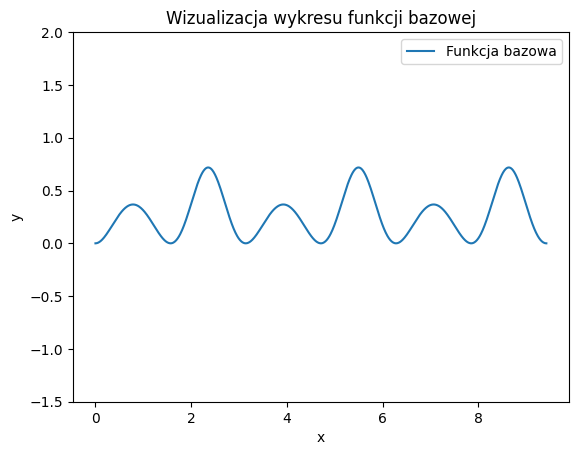

In [7]:
def prepare_function(k, m) -> Callable:
    return lambda x: np.pow(np.e, -k * np.sin(m*x)) + k * np.sin(m*x) - 1

def prepare_derivative(k, m) -> Callable:
    return lambda x: k * m * np.cos(m*x) - k * m * np.cos(m * x) * np.pow(np.e, -k * np.sin(m*x))

function = prepare_function(k=1, m=2)
derivative = prepare_derivative(k=1, m=2)

interval = (np.float64(0), np.float64(3*np.pi))
y_lim = (-1.5, 2)

xs = np.linspace(interval[0], interval[1], 1000)
ys = [function(x) for x in xs]
plt.ylim(y_lim)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Wizualizacja wykresu funkcji bazowej")
plt.plot(xs, ys, label="Funkcja bazowa")
plt.legend()
plt.show()

Benchmark interpolacji

In [8]:
ns = [i for i in range(2, 101)]
file_name = "error_data.csv"

error_data_df = pd.DataFrame(columns=["n", "Interpolation", "Max Error", "Root Mean Squared Error"])

for n in ns:
    uniform_nodes = generate_uniform_nodes(n, interval, function)

    quadratic_uniform_free = quadratic_spline_interpolation(uniform_nodes, derivative, "f")
    quadratic_uniform_clamped = quadratic_spline_interpolation(uniform_nodes, derivative, "c")

    cubic_uniform_free = cubic_spline_interpolation(uniform_nodes, "f")
    cubic_uniform_nk = cubic_spline_interpolation(uniform_nodes, "nk")

    interpolations = [(quadratic_uniform_free, "quadratic_uniform_free"),
                      (quadratic_uniform_clamped, "quadratic_uniform_clamped"),
                      (cubic_uniform_free, "cubic_uniform_free"),
                      (cubic_uniform_nk, "cubic_uniform_nk")]

    for interpolation, interpolation_name in interpolations:
        max_error_value = max_error(function, interpolation, interval)
        root_mean_squared_error_value = root_mean_squared_error(function, interpolation, interval)

        error_data_df.loc[len(error_data_df)] = {
            "n": n,
            "Interpolation": interpolation_name,
            "Max Error": max_error_value,
            "Root Mean Squared Error": root_mean_squared_error_value,
        }
        

error_data_df.to_csv(file_name, index=False)

In [9]:
def visualize_error_data(file_name, df, title, log_scale=False):

    ax = df.plot(
        x="n",
        y="Max Error",
        label="Max Error",
        color="green"
    )
    df.plot(
        x="n",
        y="Root Mean Squared Error",
        label="RMSE",
        color="red",
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel('Liczba węzłów')
    if log_scale:
        ax.set_yscale("log")

    plt.legend()
    plt.savefig(file_name)
    plt.close()

In [10]:
file_name = "error_data.csv"
directory = "plots/error/"

if not os.path.exists(directory):
    os.makedirs(directory)

df = pd.read_csv(file_name)

base_filter = df["Interpolation"] == "quadratic_uniform_free"
visualize_error_data("plots/error/quadratic_uniform_free", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 2-go stopnia\nz warunkiem wolnym")
visualize_error_data("plots/error/quadratic_uniform_free_log", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 2-go stopnia\nz warunkiem wolnym w skali logarytmicznej", log_scale=True)

base_filter = df["Interpolation"] == "quadratic_uniform_clamped"
visualize_error_data("plots/error/quadratic_uniform_clamped", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 2-go stopnia\nz warunkiem zaciśniętym")
visualize_error_data("plots/error/quadratic_uniform_clamped_log", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 2-go stopnia\nz warunkiem zaciśniętym w skali logarytmicznej", log_scale=True)

base_filter = df["Interpolation"] == "cubic_uniform_free"
visualize_error_data("plots/error/cubic_uniform_free", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 3-go stopnia\nz warunkiem wolnym")
visualize_error_data("plots/error/cubic_uniform_free_log", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 3-go stopnia\nz warunkiem wolnym w skali logarytmicznej", log_scale=True)

base_filter = df["Interpolation"] == "cubic_uniform_nk"
visualize_error_data("plots/error/cubic_uniform_nk", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 3-go stopnia\nz warunkiem not-a-knot")
visualize_error_data("plots/error/cubic_uniform_nk_log", df[base_filter], "Wizualizacja błędów interpolacji funkcjami sklejanymi 3-go stopnia\nz warunkiem not-a-knot w skali logarytmicznej", log_scale=True)


In [11]:
def visualize_interpolation(
    interval: tuple[np.float64, np.float64],
    interpolation: Callable,
    function: Callable,
    nodes,
    y_lim = None,
    interpolation_label: str = "",
    nodes_label: str = "",
):
    xs = np.linspace(interval[0], interval[1], 1000)

    polynomial_ys = np.array([interpolation(x) for x in xs])
    function_ys = np.array([function(x) for x in xs])

    plt.scatter(nodes[:, 0], nodes[:, 1], color='purple', label=nodes_label)
    plt.plot(xs, function_ys, label="Funkcja bazowa")
    plt.plot(xs, polynomial_ys, label=interpolation_label)
    if y_lim:
        plt.ylim(y_lim)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()

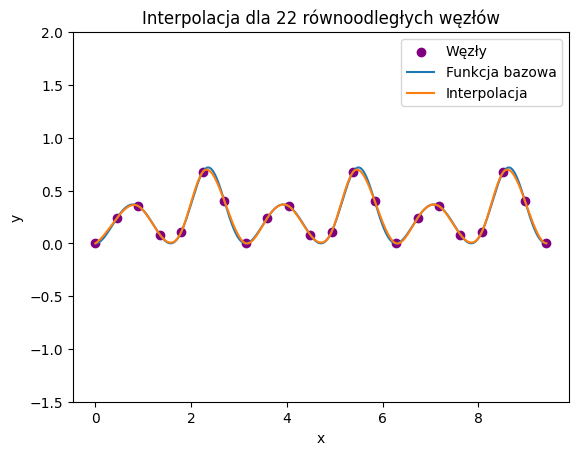

In [12]:
ns = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 22]
for n in ns:
    uniform_nodes = generate_uniform_nodes(n, interval, function)

    quadratic_uniform_free = quadratic_spline_interpolation(uniform_nodes, derivative, "f")
    quadratic_uniform_clamped = quadratic_spline_interpolation(uniform_nodes, derivative, "c")

    cubic_uniform_free = cubic_spline_interpolation(uniform_nodes, "f")
    cubic_uniform_nk = cubic_spline_interpolation(uniform_nodes, "nk")

    interpolations = [(quadratic_uniform_free, uniform_nodes, "quadratic_uniform_free", "plots/quadratic"),
                      (quadratic_uniform_clamped, uniform_nodes, "quadratic_uniform_clamped", "plots/quadratic"),
                      (cubic_uniform_free, uniform_nodes, "cubic_uniform_free", "plots/cubic"),
                      (cubic_uniform_nk, uniform_nodes, "cubic_uniform_nk", "plots/cubic")]
    
    for interpolation, nodes, interpolation_name, directory in interpolations:
        if not os.path.exists(directory):
           os.makedirs(directory)
        plt.clf()
        visualize_interpolation(interval, interpolation, function, nodes, interpolation_label="Interpolacja", nodes_label="Węzły", y_lim=y_lim)
        plt.title(f"Interpolacja dla {n} równoodległych węzłów")
        plt.savefig(f"{directory}/{interpolation_name}_{n}")
